In [34]:
import IPython.display
from pathlib import Path
from Background_functions import call_length_stats, dp , start_end_times, split_audio_segments, read_audio_file, stft_calculation, plot_spectrogram, resample_audio
import numpy as np
from scipy.spatial import distance as dist
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")


In [35]:
#store start and end times in array
text = DATA_22 / "20230422_171301.Detections.selections.txt"
df, start_t, end_t = start_end_times(text)

average_call_length, longest_call_length, shortest_call_length = call_length_stats(df)

In [36]:
#Clip wanted audio segment from the original audio file
audio = DATA_22 / "20230422_171301.WAV"
f_s, x = read_audio_file(audio)

audio_segments = split_audio_segments(x, f_s, start_t, end_t)

IPython.display.Audio(audio_segments[0], rate=f_s)

This is first try of calculateing STFT

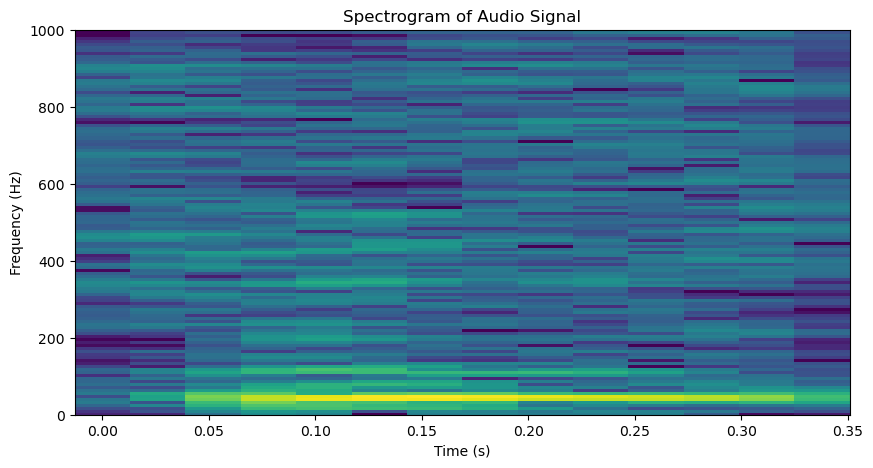

In [37]:
#Calculate the STFT of the audio segment
fs_new = 2000
resampled_audio = resample_audio(audio_segments[0], f_s, fs_new)
f, t, Zxx = stft_calculation(resampled_audio, f_s, fs_new)
#Plot the spectrogram of the audio segment
plot_spectrogram(f, t, Zxx, fs_new)

This is the first implementation of STFT with DTW

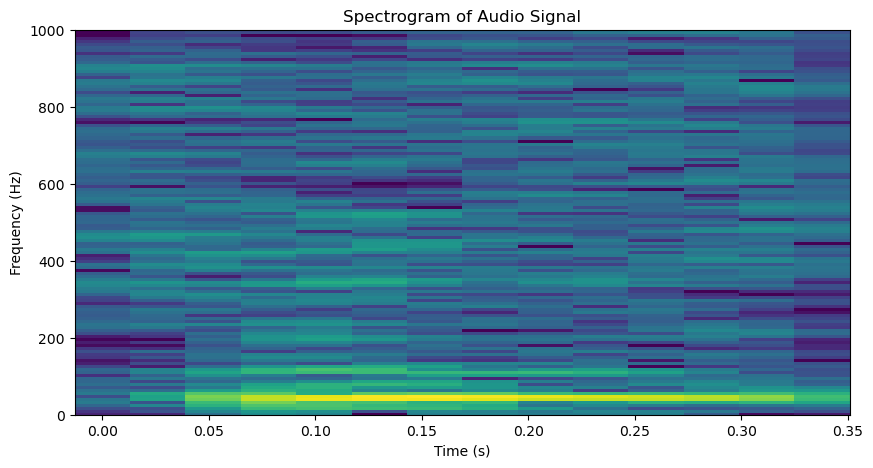

In [38]:
template = resample_audio(audio_segments[0], f_s, fs_new)
comparison = resample_audio(audio_segments[10], f_s, fs_new)

template_f, template_t, template_Zxx = stft_calculation(template, f_s, fs_new)
comparison_f, comparison_t, comparison_Zxx = stft_calculation(comparison, f_s, fs_new)

plot_spectrogram(template_f, template_t, template_Zxx, fs_new)


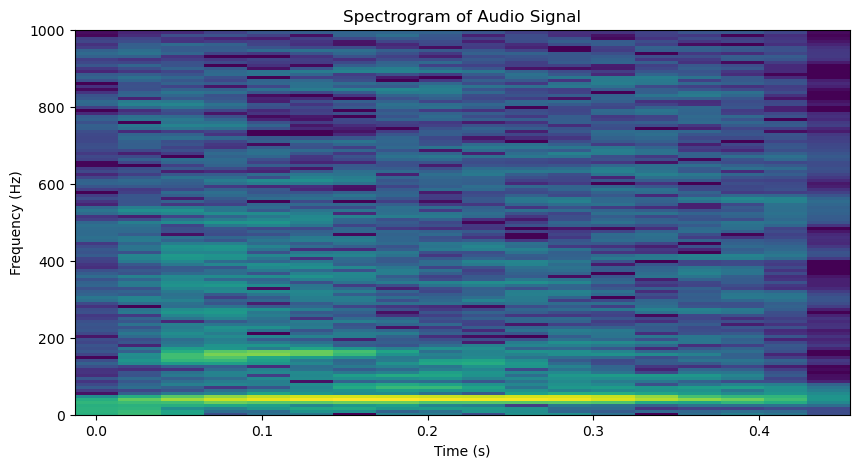

In [39]:
plot_spectrogram(comparison_f, comparison_t, comparison_Zxx, fs_new)

In [40]:
x_seq = np.abs(template_Zxx).T      # shape: (n_time_frames, n_freq_bins)
y_seq = np.abs(comparison_Zxx).T    # shape: (n_time_frames, n_freq_bins)

dist_mat = dist.cdist(x_seq, y_seq, "cosine")
path, cost_mat = dp(dist_mat)
print("Alignment cost: {:.4f}".format(cost_mat[-1, -1]))

Alignment cost: 2.3205


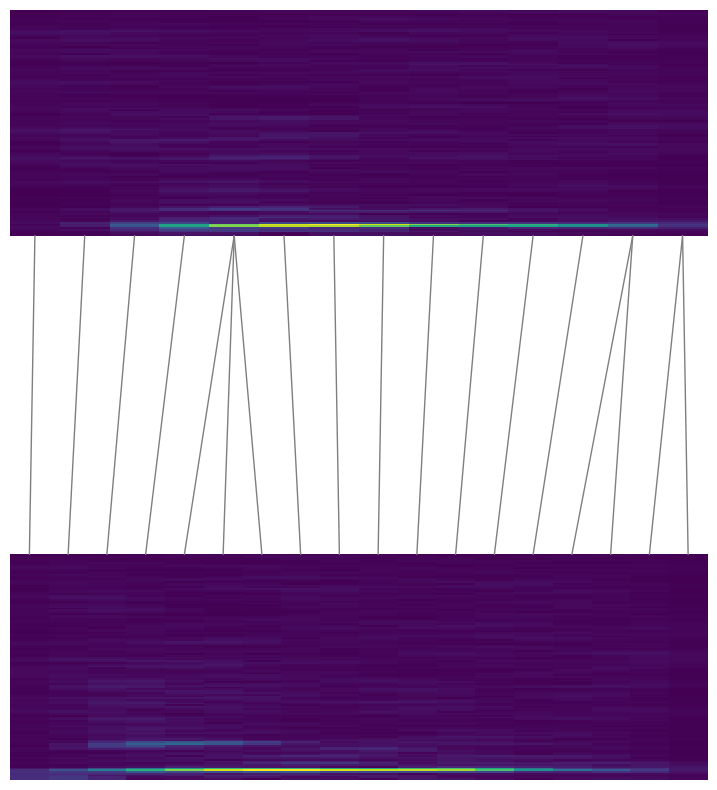

In [41]:
fig = plt.figure(figsize=(9, 10))
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(313)

ax1.imshow(np.abs(template_Zxx), origin="lower", interpolation="nearest", aspect="auto")
ax2.imshow(np.abs(comparison_Zxx), origin="lower", interpolation="nearest", aspect="auto")
ax1.axis("off")
ax2.axis("off")

for x_i, y_j in path:
    con = ConnectionPatch(
        xyA=(x_i, 0), xyB=(y_j, comparison_Zxx.shape[0] - 1), coordsA="data", coordsB="data",
        axesA=ax1, axesB=ax2, color="C7"
        )
    ax2.add_artist(con)

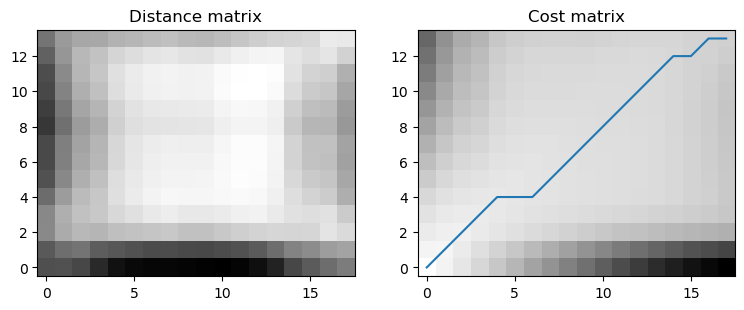

In [42]:
plt.figure(figsize=(9, 5))
plt.subplot(121)
plt.title("Distance matrix")
plt.imshow(dist_mat, cmap=plt.cm.binary, interpolation="nearest", origin="lower")
plt.subplot(122)
plt.title("Cost matrix")
plt.imshow(cost_mat, cmap=plt.cm.binary, interpolation="nearest", origin="lower")
x_path, y_path = zip(*path)
plt.plot(y_path, x_path);